# Using AI to gain a better understandig of BBD-PS-InSAR Time Series

## Problem

In [1]:
from IPython.core.display import HTML 

# Data preparation

## Imports and Drive-Connection

In [2]:
!pip install tensorflow

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from numpy import datetime64
import re
import tensorflow as tf
print(tf.__version__)
tf.get_logger().setLevel('ERROR')


I0000 00:00:1790347579.967500   21149 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790347581.587831   21149 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0


## Hyperparameters

In [4]:
window_size = 10
batch_size = 32
shuffle_buffer = 1000

## Data

Some data is missing due to orbitting reasons. Do interpolation.

In [5]:

df=pd.read_csv('52028209n.csv')


df.head()

df.iloc[0]

date_20150401    0.000000
date_20150413   -7.013970
date_20150425   -4.924180
date_20150507   -4.619620
date_20150531   -3.693010
                   ...   
date_20211125   -5.804410
date_20211201   -0.312103
date_20211207   -6.326710
date_20211213   -0.969059
date_20211219   -0.227574
Name: 0, Length: 348, dtype: float64

## Adding missing days

In [6]:
# Get acquisition dates from column names
day_flag = 'date_'
regxx = day_flag

dats   = []
nodats = []
for c in df.columns:
    if re.findall(regxx,c):
        dats.append(c)
    else:
        nodats.append(c)
        
dt_dats = [datetime64(c[5:9]+'-'+c[9:11]+'-'+c[11:13]) for c in dats]


In [7]:
# fill in missing dates

dt_dats_padded = [dt_dats[0]]

old_date = dt_dats[0]
while old_date<dt_dats[-1]:
    old_date += 6
    dt_dats_padded.append(old_date)

#print(dt_dats_padded)

dt_dats_asDays = (dt_dats-dt_dats[0]).astype('float')
dt_dats_asDays_padded = (dt_dats_padded-dt_dats_padded[0]).astype('float')

print(type(dt_dats_asDays_padded),type(dt_dats_asDays))
print(len(dt_dats_padded), len(dt_dats_asDays_padded))


<class 'numpy.ndarray'> <class 'numpy.ndarray'>
410 410


/tmp/ipykernel_21149/2079547032.py:7: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  old_date += 6


In [8]:
# Interpolate values


this_ps = df.iloc[0]
this_ts = this_ps[dats]
this_mv = this_ps[nodats]
# padding missing values in a six-day rhythm
# with linearly interpolated data

# allocating new lists
#this_ts_padded = [this_ts.iloc[0]]

# fill in missing values
this_ts_padded = np.interp(dt_dats_asDays_padded, dt_dats_asDays, this_ts.astype('float'))
#print(np.max(this_ts_padded), np.min(this_ts_padded))
n_max = np.max(this_ts_padded)
n_min = np.min(this_ts_padded)

this_ps_padded = [*this_mv, *this_ts_padded]
this_ps_padded = np.asarray(this_ps_padded).T



   

## Plot Observed Data

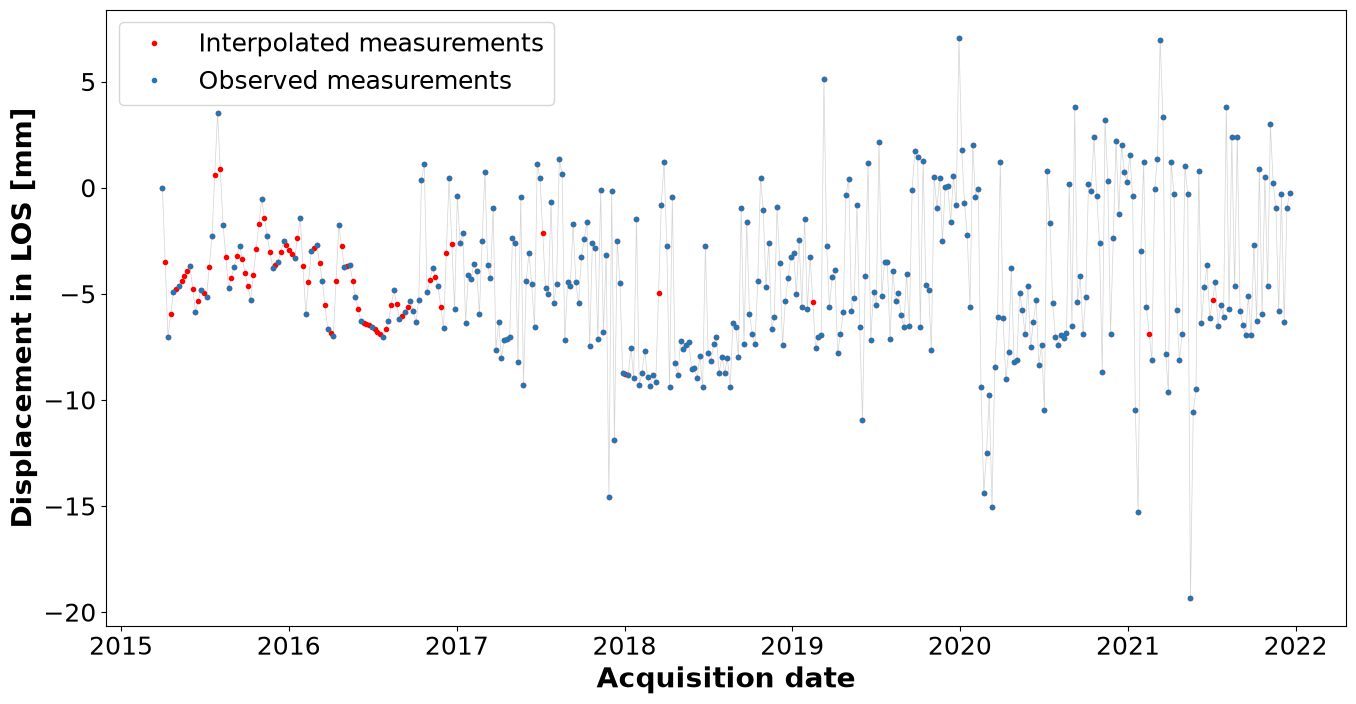

In [9]:
plt.rcParams['figure.facecolor'] = 'white'
plt.figure(figsize=[16,8])
plt.plot(dt_dats_padded, this_ps_padded,color='lightgray', linewidth=0.5)
plt.plot(dt_dats_padded, this_ps_padded,'r.', label='Interpolated measurements')
plt.plot(dt_dats, this_ps.values,'.', label='Observed measurements')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

## Detrending - take care of "%%script"-option

In [10]:
%%script echo skipping
series2 = np.copy(series) # make a copy!

myfit = np.polyfit(time, series,1)
mytrend = np.polyval(myfit, time)

series_trendfree = [i-j for i,j in zip(series,mytrend)]
series_trendfree = np.asarray(series_trendfree)
print(np.min(series_trendfree))


plt.figure(figsize=[16,9])
plt.plot(time, series)
plt.plot(time, series_trendfree, 'r', linewidth=3)

skipping


In [11]:
# Decide, what data to use: series or the trendfree one
# THIS IS THE POINT TO START OVER WHEN SOMETHING WENT WRONG

time = dt_dats_asDays_padded
this_signal = this_ps_padded #or
#signal = series_trendfree

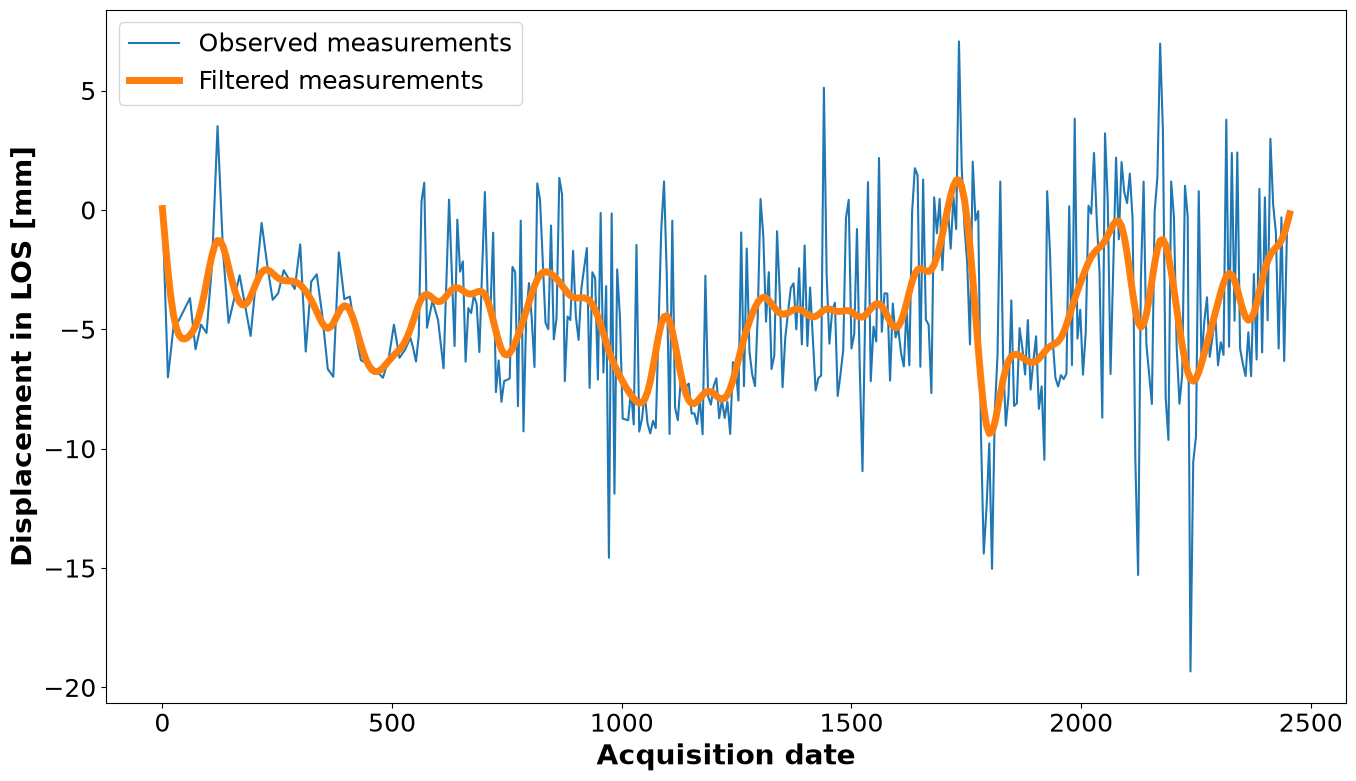

In [12]:
from scipy import signal

omega_g = 1./90      #cut off frequency
fs      = 1./6     

this_omega_g = omega_g
sos = signal.butter(3, this_omega_g, 'lp', fs=fs, output='sos')
this_signal_filtered = signal.sosfiltfilt(sos, this_signal)

plt.figure(figsize=[16,9])
plt.plot(time, this_signal, label='Observed measurements')
plt.plot(time, this_signal_filtered, linewidth=5, label='Filtered measurements')

this_signal = this_signal_filtered
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)


In [13]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Generates dataset windows

    Args:
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the feature
      batch_size (int) - the batch size
      shuffle_buffer(int) - buffer size to use for the shuffle method

    Returns:
      dataset (TF Dataset) - TF Dataset containing time windows
    """
  
    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)
    
    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    
    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Create tuples with features and labels 
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Shuffle the windows
    dataset = dataset.shuffle(shuffle_buffer)
    
    # Create batches of windows
    dataset = dataset.batch(batch_size).prefetch(1)
    
    return dataset

## **Split dataset**

In [14]:
# Define the split time
split_time = 340



# Get the train set 
time_train = time[:split_time]
x_train = this_signal[:split_time]

# Get the validation set
time_valid = time[split_time:]
x_valid = this_signal[split_time:]

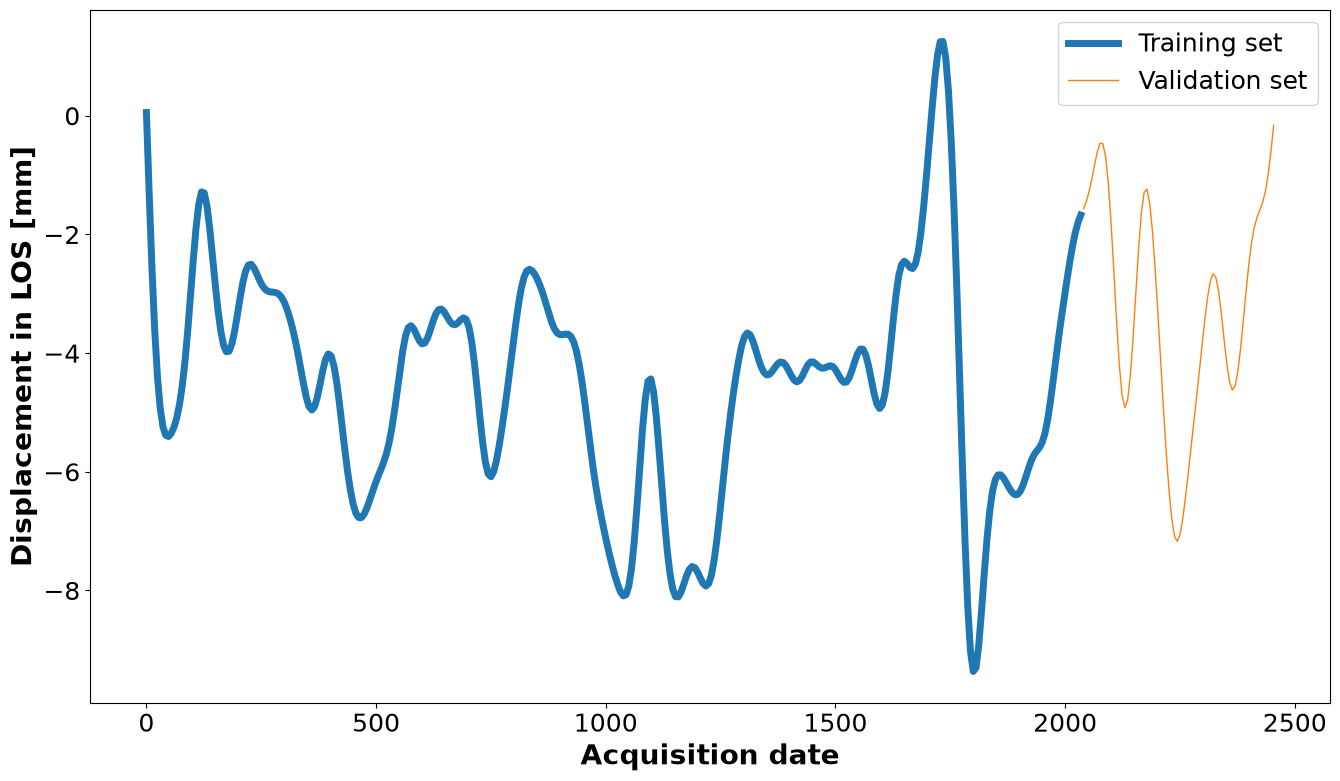

In [15]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, linewidth=5, label='Training set')
plt.plot(time_valid, x_valid, linewidth=1, label='Validation set')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

In [16]:
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer)

# The AI-part

## The model [2]

There's another model at the end of this notebook: the "Sunspot model" from Coursera's Tensorflow Time Series Course (where this is taken from, too).

In [22]:
#%%script echo skipping


# Reset states generated by Keras
tf.keras.backend.clear_session()

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size, 1)),
    tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        padding="causal",
        activation="relu",
    ),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 20.),
])

In [23]:
#model = tf.keras.models.load_model('./model/experiment001/')

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Train the model

In [35]:
# Match the model's expected shapes:
# inputs: [batch, window_size, 1], targets: [batch, 1]
train_set_3d = train_set.map(
    lambda x, y: (
        tf.cast(x[..., tf.newaxis], tf.float32),
        tf.cast(y[..., tf.newaxis], tf.float32),
    )
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
)

history = model.fit(
    train_set_3d,
    epochs=400,
    verbose=2,
)

Epoch 1/400
11/11 - 3s - 272ms/step - loss: 3.8384
Epoch 2/400
11/11 - 0s - 13ms/step - loss: 1.0182
Epoch 3/400
11/11 - 0s - 12ms/step - loss: 0.2265
Epoch 4/400
11/11 - 0s - 12ms/step - loss: 0.1127
Epoch 5/400
11/11 - 0s - 12ms/step - loss: 0.0565
Epoch 6/400
11/11 - 0s - 12ms/step - loss: 0.0334
Epoch 7/400
11/11 - 0s - 12ms/step - loss: 0.0189
Epoch 8/400
11/11 - 0s - 12ms/step - loss: 0.0164
Epoch 9/400
11/11 - 0s - 12ms/step - loss: 0.0144
Epoch 10/400
11/11 - 0s - 12ms/step - loss: 0.0154
Epoch 11/400
11/11 - 0s - 12ms/step - loss: 0.0141
Epoch 12/400
11/11 - 0s - 11ms/step - loss: 0.0133
Epoch 13/400
11/11 - 0s - 11ms/step - loss: 0.0133
Epoch 14/400
11/11 - 0s - 12ms/step - loss: 0.0135
Epoch 15/400
11/11 - 0s - 12ms/step - loss: 0.0147
Epoch 16/400
11/11 - 0s - 11ms/step - loss: 0.0121
Epoch 17/400
11/11 - 0s - 12ms/step - loss: 0.0120
Epoch 18/400
11/11 - 0s - 12ms/step - loss: 0.0118
Epoch 19/400
11/11 - 0s - 11ms/step - loss: 0.0115
Epoch 20/400
11/11 - 0s - 11ms/step - l

## Now, let's make some predictions

In [36]:

# Initialize a list
forecast = []

# Reduce the original series
forecast_series = this_signal[split_time - window_size:]

# Use the model to predict data points per window size
for time1 in range(len(forecast_series) - window_size):
  forecast.append(model.predict(forecast_series[time1:time1 + window_size][np.newaxis]))

# Convert to a numpy array and drop single dimensional axes
results = np.array(forecast).squeeze()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

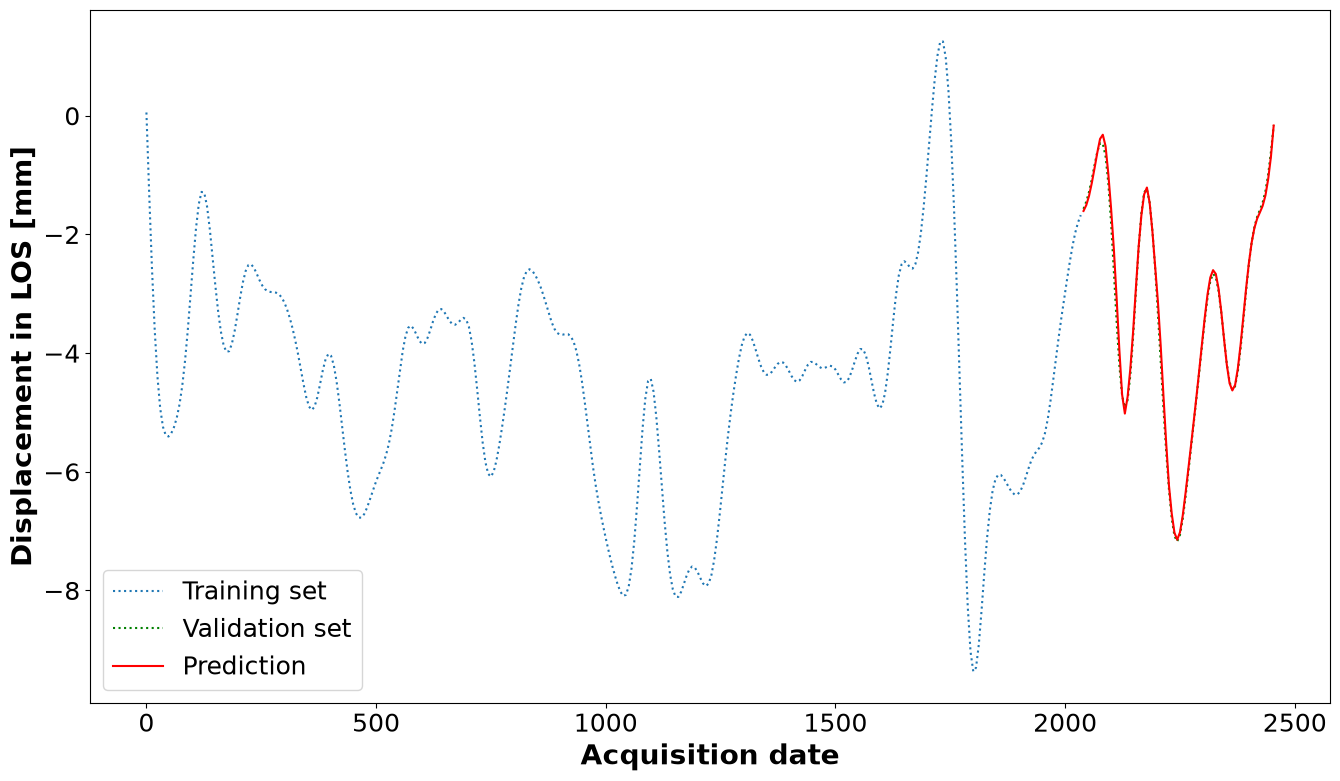

In [37]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, ':', label='Training set')
plt.plot(time_valid, x_valid, ':', color='green', label='Validation set')
plt.plot(time_valid, results,'-',color='red', label='Prediction')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.savefig('pred.png')

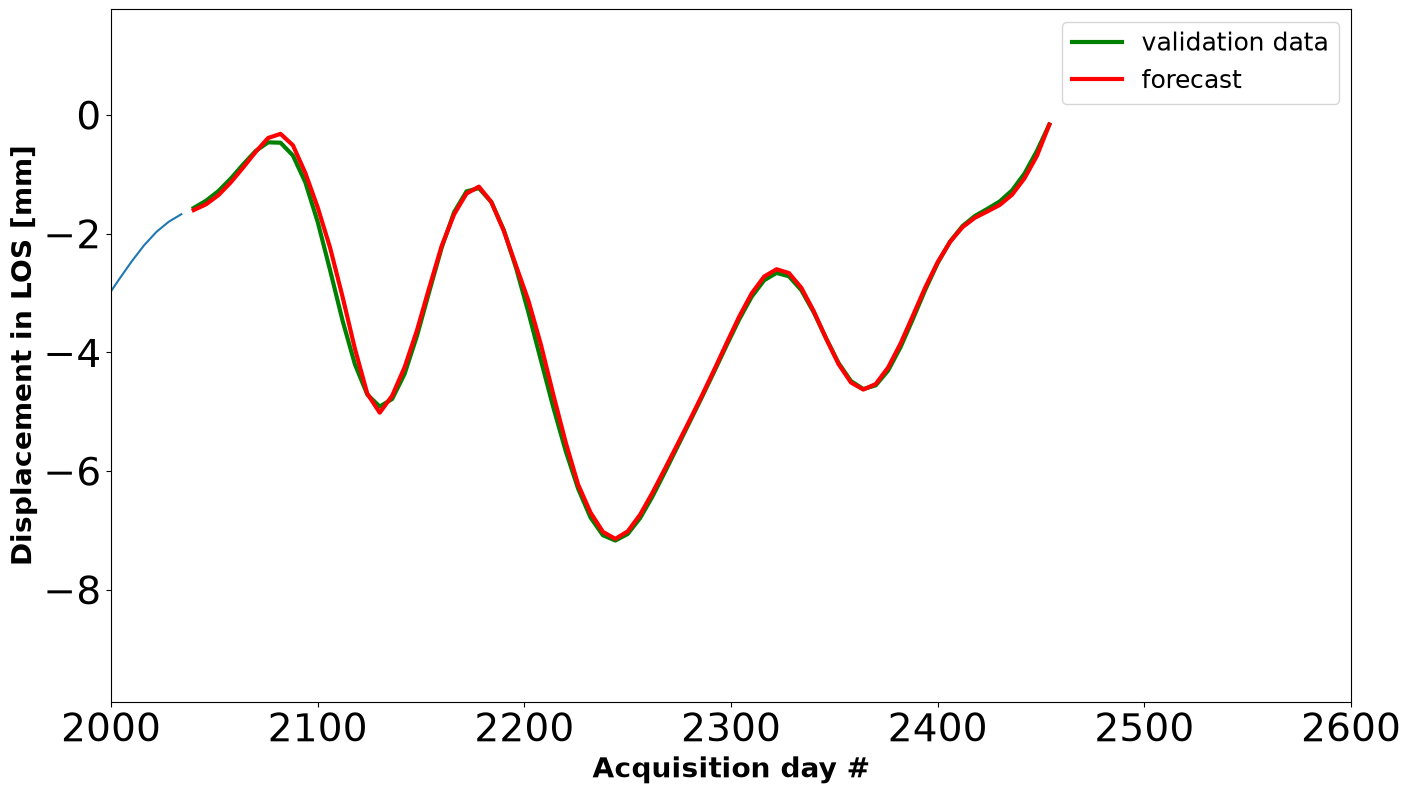

In [38]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train)
plt.plot(time_valid, x_valid, color='green', linewidth=3, label= 'validation data')
plt.plot(time_valid, results, color='red', linewidth=3, label='forecast')
plt.legend()
plt.xlim([2000,2600])
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition day #', fontsize=20, fontweight='bold')
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=18)

In [ ]:
# Compute the metrics
print(tf.keras.metrics.mean_squared_error(x_valid, results).numpy())
print(tf.keras.metrics.mean_absolute_error(x_valid, results).numpy())

# Own Predictions

What happens, if we use our predictions as input for further predictions

In [ ]:
# Initialize a list
native_forecast = []


# Reduce the original series
native_forecast_window = this_signal[split_time - window_size:split_time]

print(len(native_forecast_window))
# Use the model to predict data points per window size
for time1 in range(len(x_valid)):
  nft = model.predict(native_forecast_window[0:][np.newaxis])
  native_forecast.append(nft)
  native_forecast_window=np.append(native_forecast_window[1:],nft)


# Convert to a numpy array and drop single dimensional axes
native_results = np.array(native_forecast).squeeze()

In [ ]:
# Calculate MSE

mse = []

for i,j in zip(native_results, x_valid):
  mse.append((i-j)**2)

In [ ]:

# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, label='Training set')
plt.plot(time_valid, x_valid, color='green', label= 'Validation set')
plt.plot(time_valid, results, color='red', label='Predictions using observed data')
plt.plot(time_valid, native_results, color='yellow', label='Predictions using predicitons')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.xlim([2000,2500])

plt.figure(figsize=[16,9])
plt.plot(time_valid, np.cumsum(mse))
plt.ylabel('Sum MSE', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18);
plt.yticks(fontsize=18);


Oben: Das sieht aus, als ob sich auch auf Basis nativer Vorhersagen wenigstens 30 Werte gut vorhersagen lassen. Das wären immerhin 180 Tage. Wir filtern bei 90 Tagen. Das ist das Mindestmaß, das wir berücksichtigen können müssen, entsprechend sind das 15 Werte. Danach müsste das Modell nachgesteuert werden.


In [ ]:
print(tf.keras.metrics.mean_squared_error(x_valid, native_results).numpy())
print(tf.keras.metrics.mean_absolute_error(x_valid, native_results).numpy())

## A more realistic case: what happens, if something happens?

In [ ]:
# make a deep copy of the validation data
x_valid_alt = np.copy(x_valid)

# change the data from the 10th value on
for i in range(11,len(x_valid_alt)):
  x_valid_alt[i] = x_valid_alt[i]-5

plt.figure(figsize=[16,8])
plt.plot(time_valid,x_valid, color='green', label='Validation set')
plt.plot(time_valid,x_valid_alt, color='blue', label='Altered validation set')
#plt.plot(time_valid, native_results, color='orange', label='native forecast')
plt.plot(time_valid, results, color='red', label='Predictions using observed data')

plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

## A new forecast

In [ ]:
forecast_2 = []

# Reduce the original series
forecast_series_2 = this_signal[split_time - window_size:split_time]
forecast_series_2 = np.append(forecast_series_2, x_valid_alt.copy())

# Use the model to predict data points per window size
for time1 in range(len(forecast_series_2) - window_size):
  forecast_2.append(model.predict(forecast_series_2[time1:time1 + window_size][np.newaxis]))

# Convert to a numpy array and drop single dimensional axes
results_2 = np.array(forecast_2).squeeze()

In [ ]:
plt.figure(figsize=[16,8])
plt.plot(time_valid,x_valid, color='green',linewidth=3,  label='Validation set')
plt.plot(time_valid,x_valid_alt, color='blue',linewidth=3,  label='Altered validation set')
#plt.plot(time_valid, native_results, color='orange', label='native forecast')
plt.plot(time_valid, results, color='red', linewidth=3, label='Predictions using validation set')
plt.plot(time_valid, results_2, color='orange',linewidth=3,  label='Predicitons using altered validation set')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition day #', fontsize=20, fontweight='bold')
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=18)

In [ ]:
mse_3 = []

for i,j in zip(x_valid_alt, results_2):
  mse_3.append((i-j)**2)
#print(mse_3)

plt.figure(figsize=[16,8])
plt.plot(time_valid,mse_3, 'o', label='MSE')
plt.ylabel('MSE', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18);
plt.yticks(fontsize=18);


# Additional stuff 

## The Sunspot model

Source: https://colab.research.google.com/github/https-deeplearning-ai/tensorflow-1-public/blob/main/C4/W4/ungraded_labs/C4_W4_Lab_3_Sunspots_CNN_RNN_DNN.ipynb#scrollTo=y6kJd40-0Hj9

At the end of that notebook there's more to learn about changing the learning rate while training the model.

In [ ]:
# Build the Model
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=64, kernel_size=3,
                      strides=1,
                      activation="relu",
                      padding='causal',
                      input_shape=[window_size, 1]),
  tf.keras.layers.LSTM(64, return_sequences=True),
  tf.keras.layers.LSTM(64),
  tf.keras.layers.Dense(30, activation="relu"),
  tf.keras.layers.Dense(10, activation="relu"),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Lambda(lambda x: x * 400)
])

 # Print the model summary 
model.summary()

## Annotations and References

[1] Diagram adopted from https://stats.stackexchange.com/questions/115258/comprehensive-list-of-activation-functions-in-neural-networks-with-pros-cons

[2] All models here are adopted form Model adopted from https://www.coursera.org/learn/tensorflow-sequences-time-series-and-prediction?specialization=tensorflow-in-practice


## Intro to Machine Learning

https://opencampus.sh F.O.C + super good + hybrid! + you gain 2.5/5 ECTS





## Activation Functions

<img src="images/activationfunctions.png" style="width: 600px;"/>

(Source: https://medium.com/@shrutijadon/survey-on-activation-functions-for-deep-learning-9689331ba092) 